In [1]:
%load_ext autoreload
%autoreload 2

# Compare the distribution of flux ranges from FVA for each model

In [2]:
import cobra
import pandas
import numpy as np
import matplotlib.pyplot as plt

from cobra.flux_analysis import flux_variability_analysis

from utilities.helper_create_model import get_irreversible_model
from utilities.utils import ec_to_og_fva_mapping, cumulative_flux_variability_graph


In [3]:
models_dict = {
    'MitoCore_Original_plt': './../parameterized_plt_models/MitoCore_Original_plt.xml',
    'Mitocore_Preliminary': './../autopacmen_output/Mitocore_Preliminary/Mitocore_Preliminary_calibrated.xml',
    'Mitocore_MitoMammal': './../autopacmen_output/Mitocore_MitoMammal/Mitocore_MitoMammal_calibrated.xml',
    'Mitocore_aligned_to_Human1': './../autopacmen_output/Mitocore_aligned_to_Human1/Mitocore_aligned_to_Human1_calibrated.xml',
}

# 1) Perform "normal" FVA for every model

- reversible reactions should be split into forward and reverse reactions
- parallel reactions should be mapped to original reactions

In [4]:
# get original reactions
og_model = cobra.io.read_sbml_model(models_dict["MitoCore_Original_plt"])
irreversible_og_model = get_irreversible_model(og_model, "_TG_")
original_model_reactions = [reaction.id for reaction in irreversible_og_model.reactions]

fva_normal_results_dict = {}
fva_normal_results_mapped_dict = {}

# perform fva and store results
for key, value in models_dict.items():
    df_mapped = pandas.DataFrame(index=original_model_reactions, columns=["minimum", "maximum"])

    # load model
    model = cobra.io.read_sbml_model(value)
    model = get_irreversible_model(model, "_TG_", no_gpr_split=True)
    
    # for reaction in model.reactions:
    #     if reaction.upper_bound == 1000:
    #         reaction.upper_bound = 100
        
    df_fva = flux_variability_analysis(model, fraction_of_optimum = 0.95, processes = 4)
    
    fva_normal_results_dict[key] = df_fva
    mapped_results_df = ec_to_og_fva_mapping(df_fva, original_model_reactions, model)
            
    fva_normal_results_mapped_dict[key] = mapped_results_df

c:\Users\emanuel.lange\.conda\envs\smoment\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\smoment\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\smoment\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\smoment\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\smoment\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")


MitoCore_Original_plt
Mitocore_Preliminary
Mitocore_MitoMammal
Mitocore_aligned_to_Human1


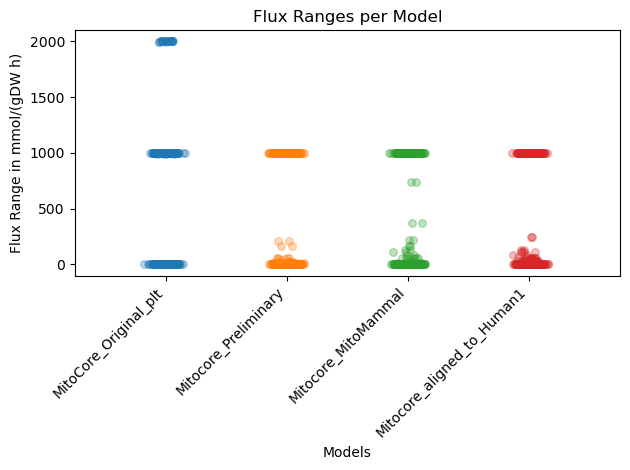

In [5]:
from utilities.utils import fva_scatter_plot

fva_scatter_plot(fva_normal_results_mapped_dict)

c:\Users\emanuel.lange\git\mitocore-smoment-model\smoment\scripts\utilities\utils.py:315: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cumulated_variabilies[model] = ranges.sum()[0]
c:\Users\emanuel.lange\git\mitocore-smoment-model\smoment\scripts\utilities\utils.py:316: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean_variabilities[model] = ranges.mean()[0]
c:\Users\emanuel.lange\git\mitocore-smoment-model\smoment\scripts\utilities\utils.py:315: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame 

Cumulated variabilities:
{'MitoCore_Original_plt': 298039.3257379789, 'Mitocore_Preliminary': 317632.6816263515, 'Mitocore_MitoMammal': 322447.46634627855, 'Mitocore_aligned_to_Human1': 309066.91346749355}
Mean variabilities:
{'MitoCore_Original_plt': 418.5945586207569, 'Mitocore_Preliminary': 361.3568619184886, 'Mitocore_MitoMammal': 363.93619226442274, 'Mitocore_aligned_to_Human1': 348.8339881122952}


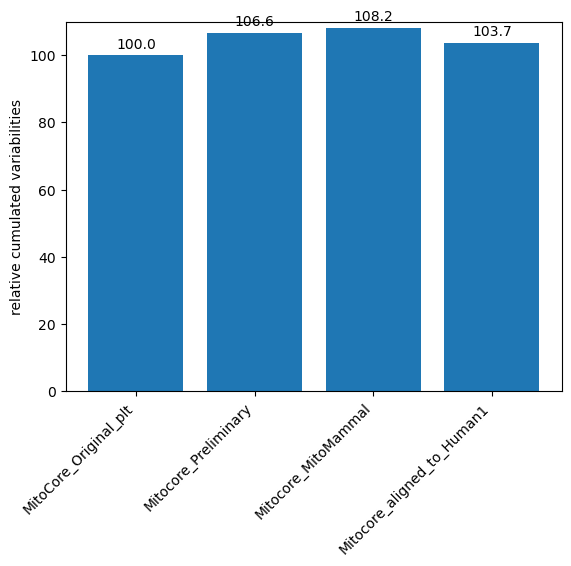

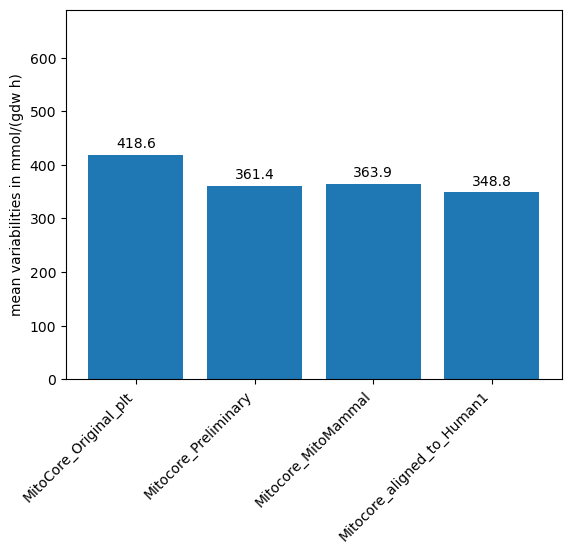

In [6]:
from utilities.utils import statistics_and_barplots

statistics_and_barplots(fva_normal_results_mapped_dict)

------------------MitoCore_Original_plt-----------------
# vars above 500: 277
# vars above 1000: 213
------------------Mitocore_Preliminary-----------------
# vars above 500: 316
# vars above 1000: 274
------------------Mitocore_MitoMammal-----------------
# vars above 500: 320
# vars above 1000: 260
------------------Mitocore_aligned_to_Human1-----------------
# vars above 500: 306
# vars above 1000: 265


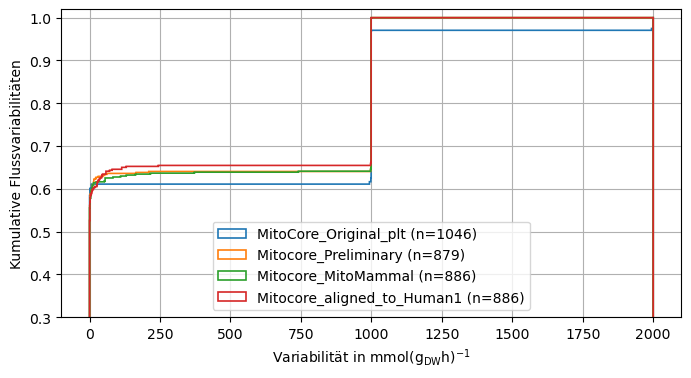

In [7]:
cumulative_flux_variability_graph(fva_normal_results_mapped_dict, '')

# 2) Perform FVA while blocking reverse reactions
- this is analogously to the original Paper by Bekiaris, where reverse reactions where blocked
- problem: loops ar blocked selectively, and there will still be loops included in the FVA predictions

In [8]:
from utilities.utils import get_fva_statistics

In [9]:
fva_ec_results_dict = {}
fva_ec_results_mapped_dict = {}

# perform fva and store results
for key, value in models_dict.items():
    df_mapped = pandas.DataFrame(index=original_model_reactions, columns=["minimum", "maximum"])

    # load model
    model = cobra.io.read_sbml_model(value)
    model = get_irreversible_model(model, "_TG_", no_gpr_split=False)

    fva_df = pandas.DataFrame.from_dict(get_fva_statistics(model, 0.95), orient='index')

    fva_ec_results_dict[key] = fva_df

    mapped_ec_results_df = ec_to_og_fva_mapping(fva_df, original_model_reactions, model)
            
    fva_ec_results_mapped_dict[key] = mapped_ec_results_df

c:\Users\emanuel.lange\.conda\envs\smoment\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")


High variability detected in reaction PCREATtmdiffirB_MitoCore_TG_forward: 1000.0000000000001


c:\Users\emanuel.lange\.conda\envs\smoment\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")
c:\Users\emanuel.lange\.conda\envs\smoment\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")


High variability detected in reaction MALSO3tm_TG_forward: 1000.0000000000001
High variability detected in reaction MALTSULtm_TG_reverse: 1000.0000000000001
High variability detected in reaction MALSO4tm_TG_forward: 1000.0000000000001
High variability detected in reaction MALSO4tm_TG_reverse: 1000.0000000000001
High variability detected in reaction r2398B_MitoCore_TG_reverse: 1000.0000000000002


c:\Users\emanuel.lange\.conda\envs\smoment\lib\site-packages\cobra\core\group.py:107: UserWarning: need to pass in a list
  warn("need to pass in a list")


High variability detected in reaction r2398B_MitoCore_TG_reverse: 1000.0000000000001


MitoCore_Original_plt
Mitocore_Preliminary
Mitocore_MitoMammal
Mitocore_aligned_to_Human1


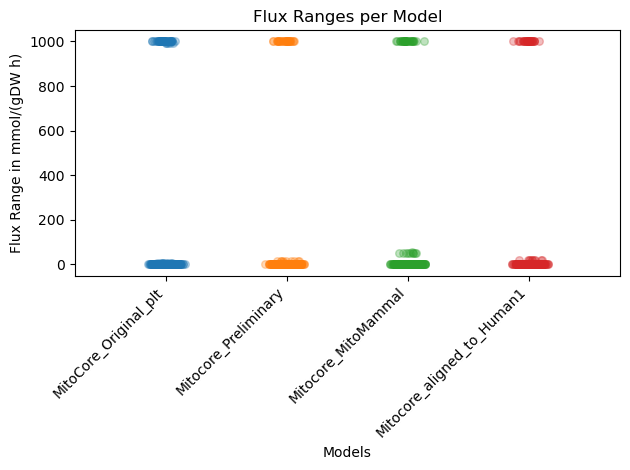

In [10]:
fva_scatter_plot(fva_ec_results_mapped_dict)

Cumulated variabilities:
{'MitoCore_Original_plt': 46083.82667410435, 'Mitocore_Preliminary': 30162.24248399343, 'Mitocore_MitoMammal': 30547.615884463678, 'Mitocore_aligned_to_Human1': 30244.72750238691}
Mean variabilities:
{'MitoCore_Original_plt': 53.89921248433257, 'Mitocore_Preliminary': 35.56868217452055, 'Mitocore_MitoMammal': 37.75972297214299, 'Mitocore_aligned_to_Human1': 35.29139731900457}


c:\Users\emanuel.lange\git\mitocore-smoment-model\smoment\scripts\utilities\utils.py:315: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  cumulated_variabilies[model] = ranges.sum()[0]
c:\Users\emanuel.lange\git\mitocore-smoment-model\smoment\scripts\utilities\utils.py:316: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mean_variabilities[model] = ranges.mean()[0]
c:\Users\emanuel.lange\git\mitocore-smoment-model\smoment\scripts\utilities\utils.py:315: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame 

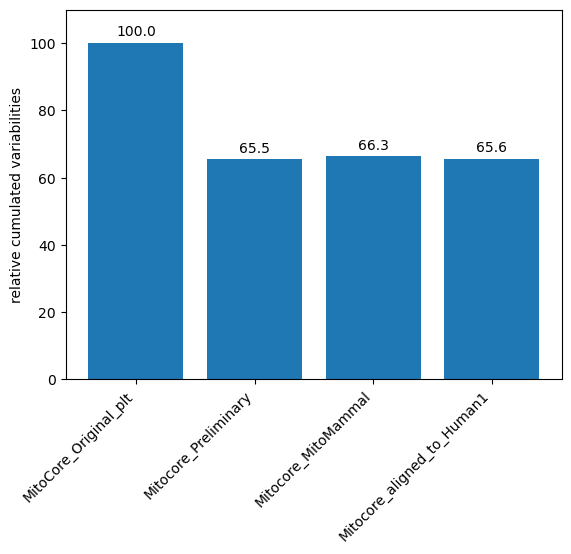

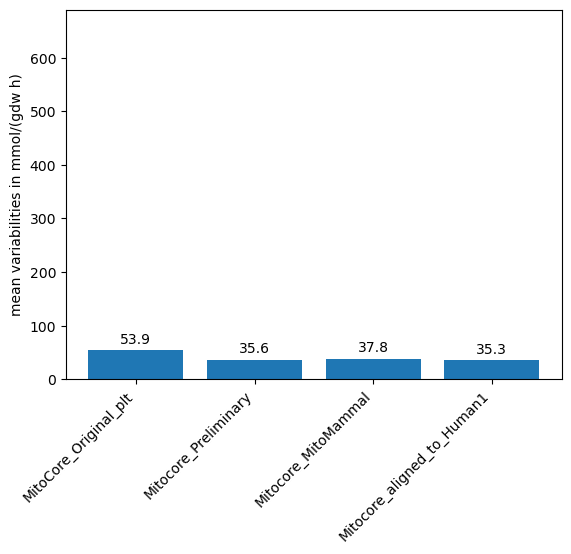

In [11]:
statistics_and_barplots(fva_ec_results_mapped_dict)

------------------MitoCore_Original_plt-----------------
# vars above 500: 46
# vars above 1000: 38
------------------Mitocore_Preliminary-----------------
# vars above 500: 30
# vars above 1000: 28
------------------Mitocore_MitoMammal-----------------
# vars above 500: 30
# vars above 1000: 24
------------------Mitocore_aligned_to_Human1-----------------
# vars above 500: 30
# vars above 1000: 28


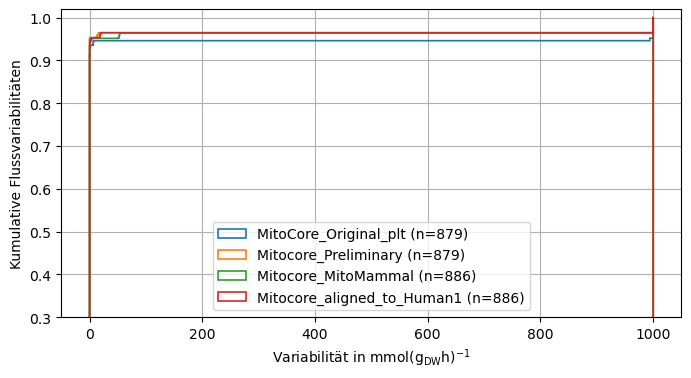

In [12]:
cumulative_flux_variability_graph(fva_ec_results_mapped_dict, '')

In [13]:
# check which reactions are still fuled by loops
fva_ec_results_mapped_dict['MitoCore_Original_plt'].loc[fva_ec_results_mapped_dict['MitoCore_Original_plt']['range'] > 100]

,range
SUCOAS1m_TG_forward,1000.0
SUCOAS1m_TG_reverse,1000.0
SUCOASm_TG_forward,1000.0
SUCOASm_TG_reverse,1000.0
NDPK1m_TG_forward,1000.0
NDPK1m_TG_reverse,1000.0
CKc_TG_forward,994.292095
CKc_TG_reverse,1000.0
CK_TG_forward,1000.0
CK_TG_reverse,994.292095
